In [93]:
import os
import numpy as np
import pandas as pd
from massfuncs import get_GSMF_Adams, get_GSMF_ELPETRO
from BAM import AbundanceMatch, proxies
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner
from ili.validation import ValidationRunner
from ili import utils
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as mcolors
import seaborn as sns

In [94]:
N_AM_REALS = 1000

STELLAR_START = 7
STELLAR_END = 11.5

M2L_DISK_MEAN = 0.5
M2L_DISK_ERROR = 0.2 # dex

M2L_BULGE_MEAN = 0.7
M2L_BULGE_ERROR = 0.2 # dex

In [95]:
# Load the N.Adams SMF data
log_stellar_masses, SMF_data, _ = get_GSMF_ELPETRO(plotting=False)

# Load the Uchuu halos 
halos = np.load("/Users/fedorboreiko/Documents/Oxford/Personal_codes/Codebase/halos_z_0p00.npy")

proxy = proxies["mvir_proxy"]()

abundance_match = AbundanceMatch(log_stellar_masses[10:], SMF_data[10:], halo_proxy=proxy, ext_range=(3.0, 12.0),
                                        boxsize=140, faint_end_first=True, scatter_mult=1, faint_end_slope=-0.42)

theta = {"alpha": 1.2, "scatter": 0.2}  # Will be tuned?
deconv = abundance_match.deconvoluted_catalogs(theta, halos)

In [96]:
def downsample(data):

    # Define the bin edges (adjust these as necessary based on your data)
    bin_edges = np.linspace(min(data[0, :]), max(data[0, :]), num=50)

    # Digitize the stellar masses into bins
    stellar_masses = data[0, :]
    bins = np.digitize(stellar_masses, bin_edges)

    # Determine the number of entries in the bin corresponding to a stellar mass of 11.5
    mass_target = 11.8
    target_bin_index = np.digitize(mass_target, bin_edges)

    # Find the number of entries in the target bin
    n_target_bin = np.sum(bins == target_bin_index)

    # Initialize a list to hold the downsampled indices
    downsampled_indices = []

    # For each bin, randomly select the same number of entries as in the target bin
    for bin_index in range(1, target_bin_index + 1):
        # Find indices of entries in this bin
        bin_indices = np.where(bins == bin_index)[0]
        
        if len(bin_indices) > 0:
            # If there are more entries than the target, downsample
            if len(bin_indices) > n_target_bin:
                selected_indices = np.random.choice(bin_indices, n_target_bin, replace=False)
            else:
                selected_indices = bin_indices
            
            downsampled_indices.append(selected_indices)

    # Flatten the list of downsampled indices
    downsampled_indices = np.concatenate(downsampled_indices)

    # Downsample the training_data using these indices
    data_downsampled = data[:, downsampled_indices]

    return data_downsampled

training_data = np.empty((3, N_AM_REALS, 336))

for i in tqdm(range(N_AM_REALS), desc="AM Realizations"):

    training_data_iteration = np.empty((3, len(halos)))

    mask, catalog_sc = abundance_match.add_scatter(deconv, cut_range=(4, 12), return_catalog=True)

    sorted_indices = np.argsort(catalog_sc)

    training_data_iteration[0, :] = catalog_sc[sorted_indices]
    training_data_iteration[1, :] = np.log10(halos['Mvir'][sorted_indices])
    training_data_iteration[2, :] = np.divide(halos['Rvir'][sorted_indices], 
                                              halos['rs'][sorted_indices], 
                                              out=np.zeros_like(halos['Rvir'][sorted_indices]), 
                                              where=halos['rs'][sorted_indices] != 0)
    
    training_data[:, i, :] = downsample(training_data_iteration)

training_data = training_data.reshape((3, N_AM_REALS * 336))

sorted_indices = np.argsort(training_data[0, :])

training_data = training_data[:, sorted_indices]

np.save("training_data_1000am_sparcind.npy", training_data)

print(training_data.shape)

AM Realizations: 100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]

(3, 336000)


Text(0.5, 1.0, 'Histogram of Downsampled Stellar Masses')

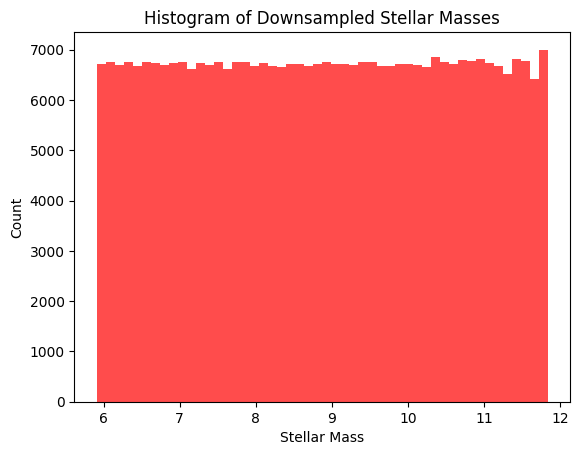

In [97]:
plt.hist(training_data[0, :], bins=50, alpha=0.7, color='red')
plt.xlabel('Stellar Mass')
plt.ylabel('Count')
plt.title('Histogram of Downsampled Stellar Masses')

Text(0, 0.5, '$\\log_{10} M_{\\star}$')

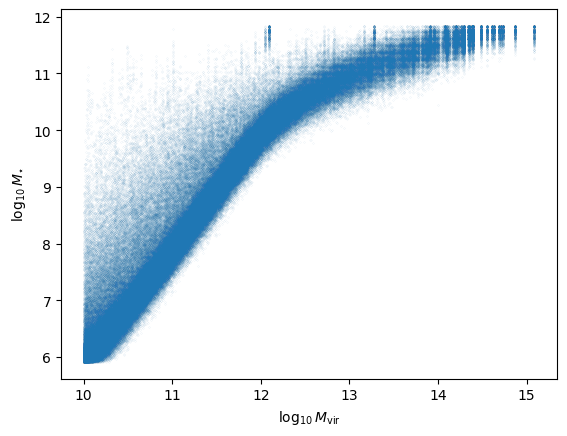

In [98]:
plt.scatter(training_data[1, :], training_data[0, :], s=0.001)
plt.xlabel(r'$\log_{10} M_{\rm vir}$')
plt.ylabel(r'$\log_{10} M_{\star}$')

(0.0, 50.0)

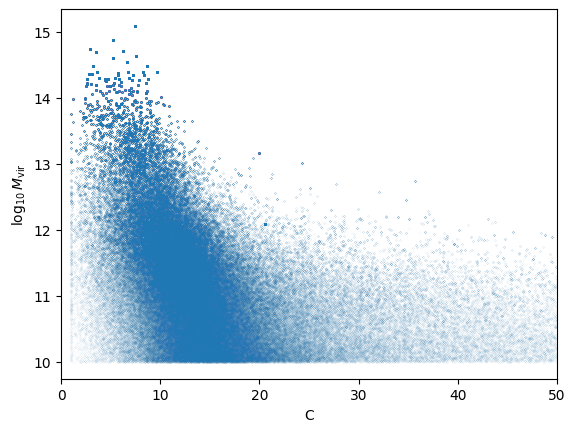

In [99]:
plt.scatter(training_data[2, :], training_data[1, :], s=0.001)
plt.xlabel("C")
plt.ylabel(r'$\log_{10} M_{\rm vir}$')
plt.xlim(0, 50)

In [100]:
loader = NumpyLoader(x=training_data[0, :].reshape(-1, 1), theta=training_data[1:, :].T)

# train a model to infer x -> theta. save it as toy/posterior.pkl
trainer = InferenceRunner.load(
  backend = 'sbi', engine='NPE',                # Choose a backend and inference engine (here, Neural Posterior Estimation)
  prior = utils.Uniform(low=[10, 1], high=[15, 50]),    # Define a prior 
  # Define a neural network architecture (here, Mixture Density Network)
  nets = [utils.load_nde_sbi(engine='NPE', model='mdn', hidden_features=10, num_components=4)],
  out_dir="1000am_sparcind_model"
)

In [101]:
posterior_ensemble, summaries = trainer(loader)

INFO:root:MODEL INFERENCE CLASS: NPE
INFO:root:Training model 1 / 1.


 Training neural network. Epochs trained: 60

/Users/fedorboreiko/Documents/Oxford/oxford_env/lib/python3.11/site-packages/sbi/utils/posterior_ensemble.py:142: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights = torch.tensor(weights) / sum(weights)
INFO:root:It took 520.448429107666 seconds to train models.
INFO:root:Saving model to 1000am_sparcind_model


 Neural network successfully converged after 61 epochs.

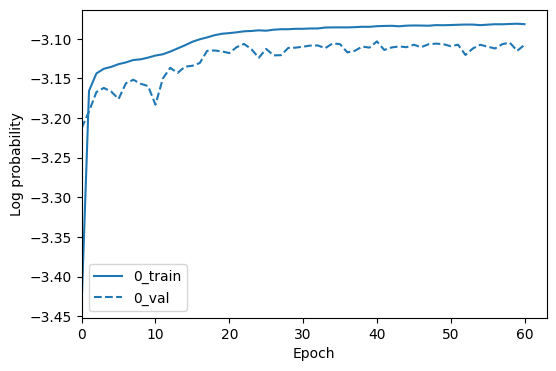

In [102]:
# plot train/validation loss
f, ax = plt.subplots(1, 1, figsize=(6,4))
c = list(mcolors.TABLEAU_COLORS)
for i, m in enumerate(summaries):
    ax.plot(m['training_log_probs'], ls='-', label=f"{i}_train", c=c[i])
    ax.plot(m['validation_log_probs'], ls='--', label=f"{i}_val", c=c[i])
ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

plt.show()

In [119]:
gal_number = "logmass6"

true_log_M_star = 6

true_Mvir_samples = np.load(f'true_Mvir_samples_galaxy_{gal_number}.npy')
true_Cs_samples = np.load(f'true_Cs_samples_galaxy_{gal_number}.npy')

posterior_ensemble = ValidationRunner.load_posterior_sbi("1000am_sparcind_model/posterior.pkl")

ltu_samples = posterior_ensemble.sample(
        (5000,), true_log_M_star
    )

ltu_log_prob = posterior_ensemble.log_prob(ltu_samples, true_log_M_star)

Drawing 5000 posterior samples: 5428it [00:00, 118175.17it/s]           


49.94235
(988, 2)


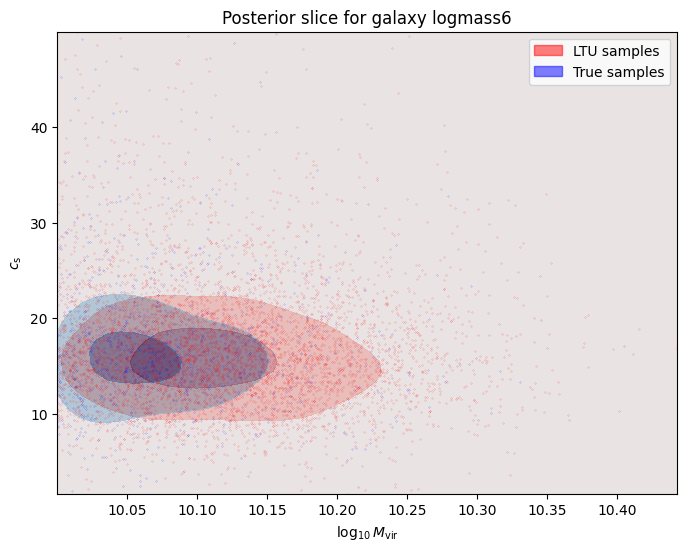

In [120]:
ltu_samples_numpy = ltu_samples.numpy()

true_samples = np.column_stack((true_Mvir_samples, true_Cs_samples))

max_ltu_cs = ltu_samples_numpy[:, 1].max()

print(max_ltu_cs)

true_samples = true_samples[true_samples[:, 1] <= max_ltu_cs]

print(true_samples.shape)

from scipy.stats import gaussian_kde
from matplotlib import patches as mpatches

# Perform KDE on the data
kde_ltu = gaussian_kde(ltu_samples_numpy.T)
kde_true = gaussian_kde(true_samples.T)

# Create a grid of points
x = np.linspace(ltu_samples_numpy[:, 0].min(), ltu_samples_numpy[:, 0].max(), 50)
y = np.linspace(ltu_samples_numpy[:, 1].min(), ltu_samples_numpy[:, 1].max(), 50)

X, Y = np.meshgrid(x, y)
positions = np.vstack([X.ravel(), Y.ravel()])

Z_ltu = np.reshape(kde_ltu(positions).T, X.shape)
Z_true = np.reshape(kde_true(positions).T, X.shape)

fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(X, Y, Z_ltu, cmap='Reds', levels=2, alpha=0.7)
ax.contourf(X, Y, Z_true, cmap='Blues', levels=2, alpha=0.5)

ax.scatter(ltu_samples_numpy[:, 0], ltu_samples_numpy[:, 1], s=0.01, color='red', label='LTU samples')
ax.scatter(true_samples[:, 0], true_samples[:, 1], s=0.01, color='blue', label='True samples')

ax.set_xlabel(r'$\log_{10} M_{\rm vir}$')
ax.set_ylabel(r'$c_{\rm s}$')

# Modify the legend to display small rectangulars colored in red and blue
red_patch = mpatches.Patch(color='red', alpha=0.5, label='LTU samples')
blue_patch = mpatches.Patch(color='blue', alpha=0.5, label='True samples')
ax.legend(handles=[red_patch, blue_patch])

ax.set_title(f'Posterior slice for galaxy {gal_number}')

plt.savefig(f"posterior_slice_galaxy_{gal_number}_sparcindep.png")